# MCMC Workthrough Notebook

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
import numpy as np

from models import *
from cosmology import CosmologyMCMC

In [2]:
file = 'data/DES-Dovekie_HD.csv'

with open(file) as f:
    for i, line in enumerate(f):
        if line.startswith('VARNAMES:'):
            header_line = line
            header_idx = i
            break

cols = header_line.replace("VARNAMES:", "").split()

df = pd.read_csv(file, sep='\s+', skiprows=header_idx + 1, header=None).iloc[:, 1:]
df.columns = cols

low_z = df[df['IDSURVEY'] != 10]
high_z = df[df['IDSURVEY'] == 10]
high_z

,CID,IDSURVEY,zHD,zHEL,MU,MUERR,MUERR_VPEC,MUERR_SYS,PROBIA_BEAMS
187,1371046,10,0.07334,0.07411,37.60807,0.1792,0.0307,0.39882,1.00000
188,1318737,10,0.07374,0.07451,37.36177,0.1858,0.0305,0.06818,1.00000
199,1864053,10,0.09333,0.09422,38.14556,0.0994,0.0243,0.06934,1.00000
200,1344303,10,0.09394,0.09475,38.19696,0.2395,0.0242,0.13223,0.99969
201,1317612,10,0.10442,0.10525,38.35683,0.1256,0.0218,0.02734,0.99996
...,...,...,...,...,...,...,...,...,...
1815,1263785,10,1.06420,1.06498,44.23028,0.1451,0.0028,0.03884,0.99765
1816,1842087,10,1.08349,1.08430,44.52159,0.1518,0.0027,0.13563,0.99789
1817,1339609,10,1.12132,1.12212,44.20175,0.1075,0.0026,0.06526,0.98858
1818,1446080,10,1.13057,1.13140,44.52710,0.1585,0.0026,0.11217,0.99945


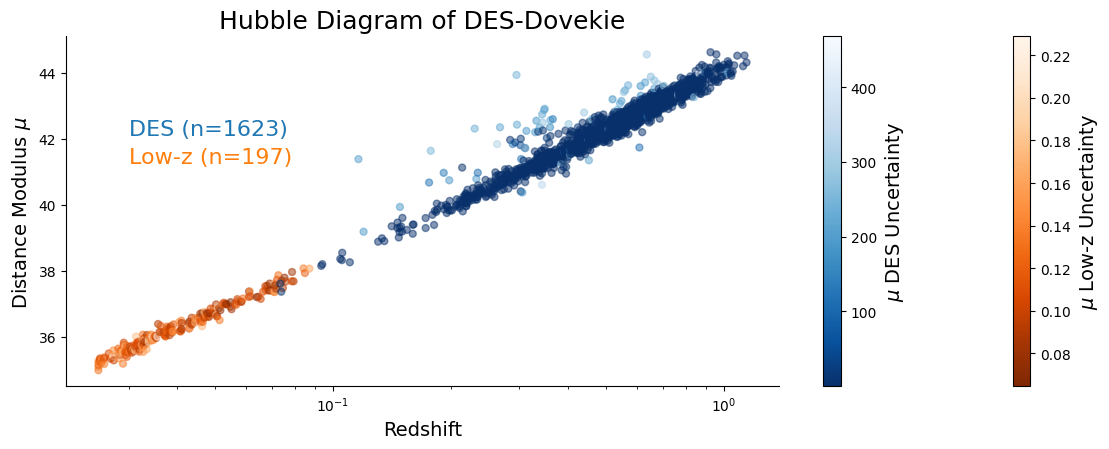

In [3]:
plt.figure(figsize=(12, 4.6))

plt.scatter(low_z['zHD'], low_z['MU'], c=low_z['MUERR'], s=25, cmap='Oranges_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ Low-z Uncertainty', size=14)
plt.scatter(high_z['zHD'], high_z['MU'], c=high_z['MUERR'], s=25, cmap='Blues_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ DES Uncertainty', size=14)


plt.xscale('log')
plt.ylabel('Distance Modulus $\mu$', size=14)
plt.xlabel('Redshift', size=14)
plt.title('Hubble Diagram of DES-Dovekie', size=18)
plt.text(0.03, 42, f"DES (n={len(high_z)})", color='tab:blue', size=16, ha='left', va='bottom')
plt.text(0.03, 41.75, f"Low-z (n={len(low_z)})", color='tab:orange', size=16, ha='left', va='top')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

remove high MU uncertainty points

In [4]:
df = df[df['MUERR'] < 0.4]

low_z = low_z[low_z['MUERR'] < 0.4]
high_z = high_z[high_z['MUERR'] < 0.4]

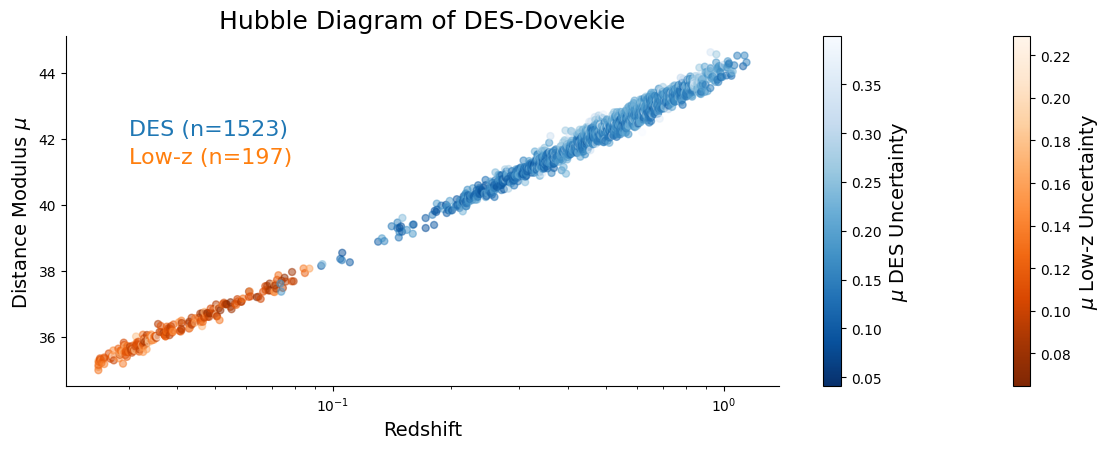

In [5]:
plt.figure(figsize=(12, 4.6))

plt.scatter(low_z['zHD'], low_z['MU'], c=low_z['MUERR'], s=25, cmap='Oranges_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ Low-z Uncertainty', size=14)
plt.scatter(high_z['zHD'], high_z['MU'], c=high_z['MUERR'], s=25, cmap='Blues_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ DES Uncertainty', size=14)


plt.xscale('log')
plt.ylabel('Distance Modulus $\mu$', size=14)
plt.xlabel('Redshift', size=14)
plt.title('Hubble Diagram of DES-Dovekie', size=18)
plt.text(0.03, 42, f"DES (n={len(high_z)})", color='tab:blue', size=16, ha='left', va='bottom')
plt.text(0.03, 41.75, f"Low-z (n={len(low_z)})", color='tab:orange', size=16, ha='left', va='top')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# MCMC

## lCDM Model

In [6]:
lcdm_sampler = CosmologyMCMC(LambdaCDMModel(), df)

n_walkers = 16
n_iterations = 2000
p0 = np.random.multivariate_normal(mean=[73, 0.3, 0.7], cov=np.diag([1, 1e-12, 1e-12]), size=n_walkers)

lcdm_sampler.test_priors(p0)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [7]:
lcdm_sampler.run_mcmc(n_walkers, n_iterations, p0)

100%|██████████| 2000/2000 [01:05<00:00, 30.46it/s]

lCDM model took 65.699 seconds


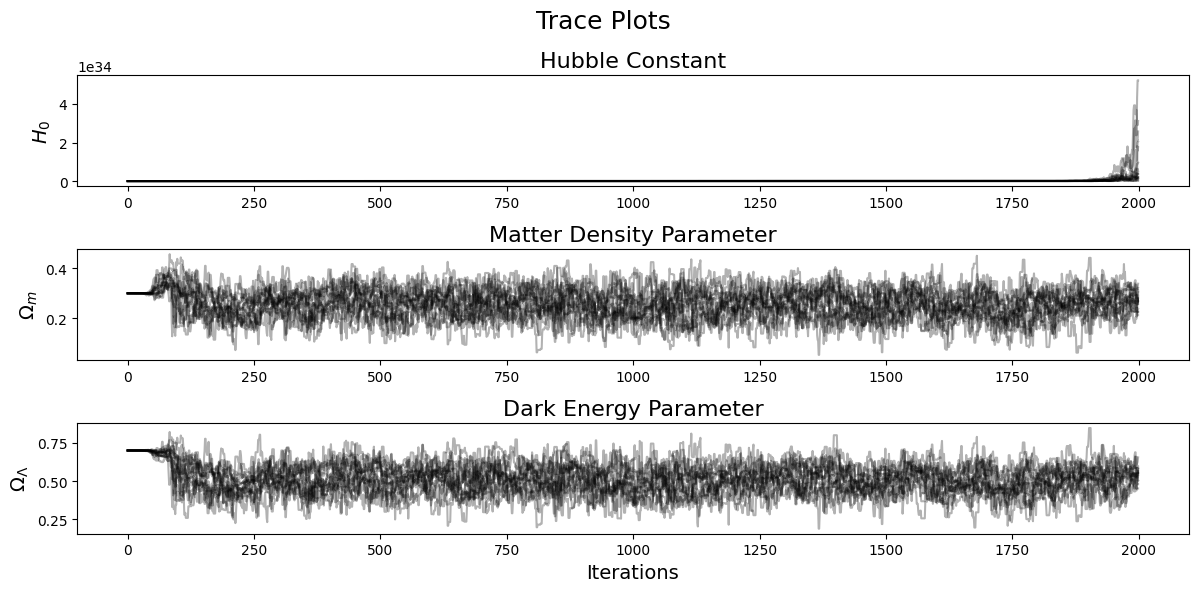

In [8]:
lcdm_sampler.trace_plots()

In [9]:
burned = pd.DataFrame(lcdm_sampler.get_samples(discard=1000, flat=True), columns=['H_0', 'Om_m', 'Om_l'])
burned['Om_k'] = 1.0 - burned['Om_m'] - burned['Om_l']
lcdm_sampler.burned = burned.sort_values(by='Om_m')

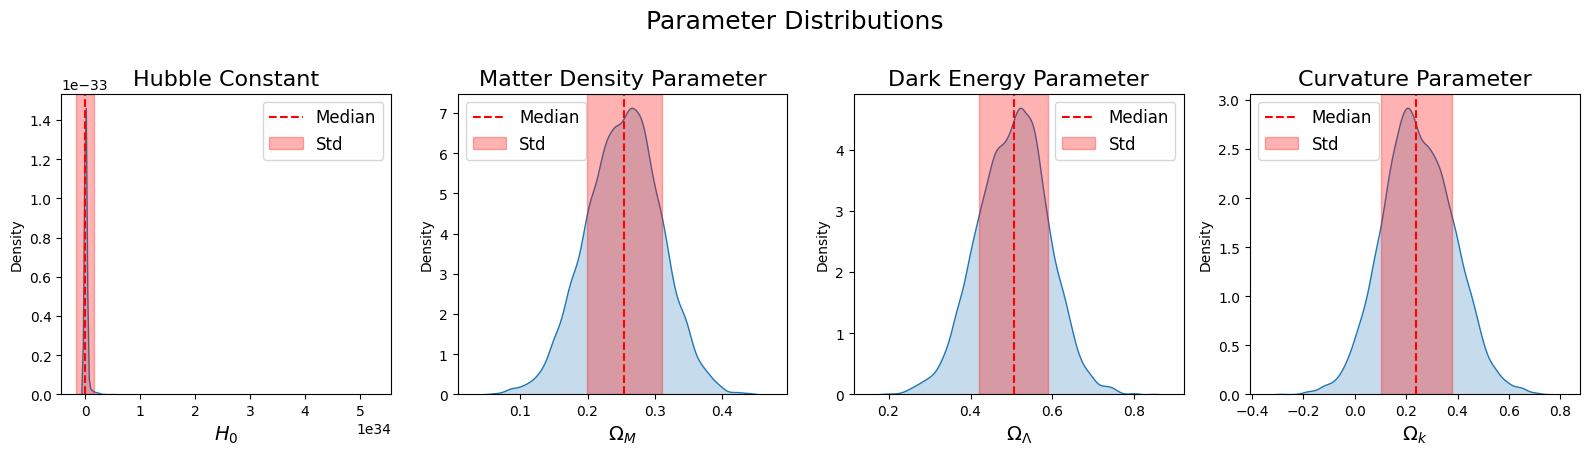

In [10]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4.6))

titles = ['Hubble Constant', 'Matter Density Parameter', 'Dark Energy Parameter', 'Curvature Parameter']
x_labels = [r'$H_0$', r'$\Omega_M$', r'$\Omega_\Lambda$', r'$\Omega_k$']
for i in range(0, 4):
    sns.kdeplot(lcdm_sampler.burned.iloc[:,i], fill=True, ax=axs[i])
    axs[i].set_xlabel(x_labels[i], size=14)
    axs[i].set_title(titles[i], size=16)
    median = np.median(lcdm_sampler.burned.iloc[:,i])
    std = np.std(lcdm_sampler.burned.iloc[:,i])
    axs[i].axvline(median, color='red', linestyle='dashed', label='Median')
    axs[i].axvspan(median-std, median+std, color='red', alpha=0.3, label='Std')
    axs[i].legend(fontsize=12)

fig.suptitle('Parameter Distributions', size=18)
plt.tight_layout()
plt.show()

In [11]:
print(f"Om_m = {lcdm_sampler.burned['Om_m'].median():.2f} ± {lcdm_sampler.burned['Om_m'].std():.2f}")
print(f"Om_l = {lcdm_sampler.burned['Om_l'].median():.2f} ± {lcdm_sampler.burned['Om_l'].std():.2f}")
print(f"Om_k = {lcdm_sampler.burned['Om_k'].median():.2f} ± {lcdm_sampler.burned['Om_k'].std():.2f}")

Om_m = 0.25 ± 0.06
Om_l = 0.51 ± 0.08
Om_k = 0.24 ± 0.14


## FlatwCDM Model

In [12]:
fwcdm_sampler = CosmologyMCMC(FlatwCDMModel(), df)

n_walkers = 16
n_iterations = 2000
p0 = np.random.multivariate_normal(mean=[73, 0.3, 0], cov=np.diag([1, 1e-12, 1e-12]), size=n_walkers)

fwcdm_sampler.test_priors(p0)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [13]:
fwcdm_sampler.run_mcmc(n_walkers, n_iterations, p0)

100%|██████████| 2000/2000 [08:50<00:00,  3.77it/s]

FlatwCDM model took 530.585 seconds


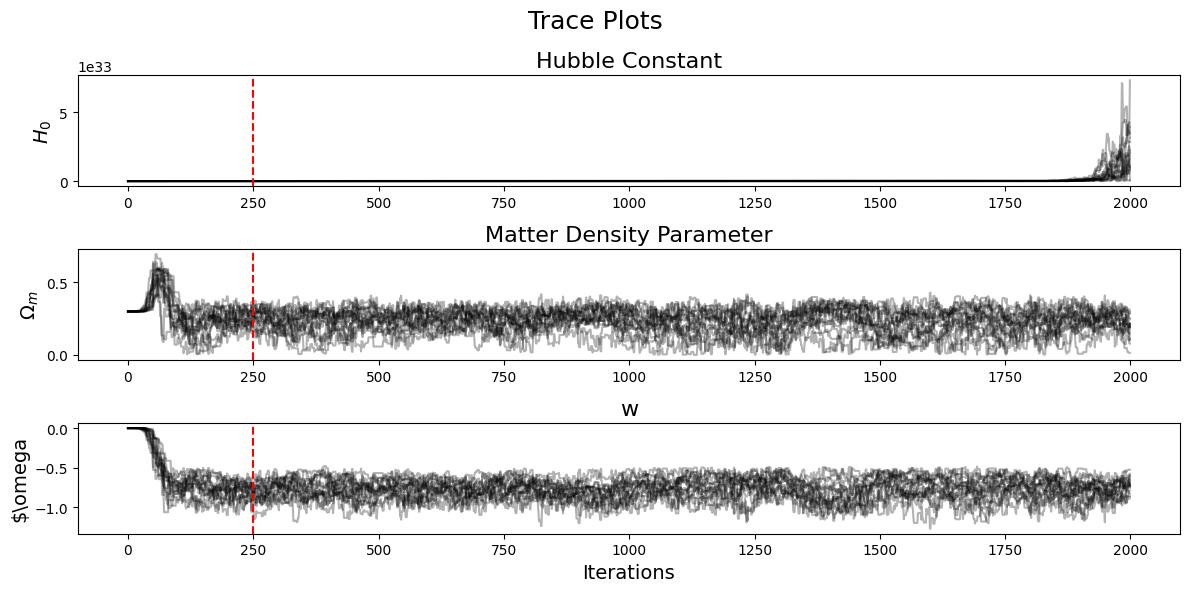

In [14]:
fwcdm_sampler.trace_plots(250)

In [15]:
fwcdm_sampler.burned = pd.DataFrame(fwcdm_sampler.get_samples(discard=250, flat=True), columns=['H_0', 'Om_m', 'w'])

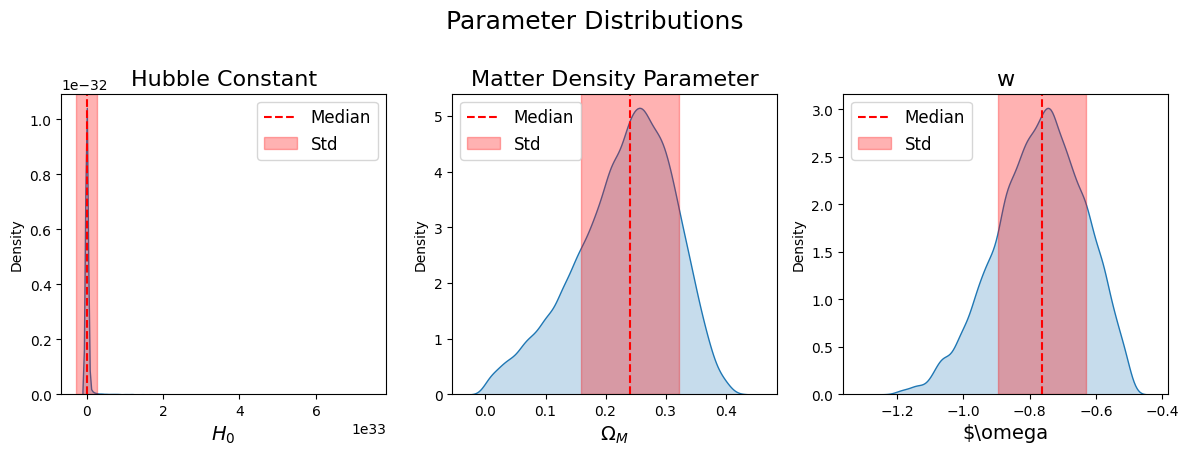

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4.6))

titles = ['Hubble Constant', 'Matter Density Parameter', 'w']
x_labels = [r'$H_0$', r'$\Omega_M$', r'$\omega']
for i in range(0, 3):
    sns.kdeplot(fwcdm_sampler.burned.iloc[:,i], fill=True, ax=axs[i])
    axs[i].set_xlabel(x_labels[i], size=14)
    axs[i].set_title(titles[i], size=16)
    median = np.median(fwcdm_sampler.burned.iloc[:,i])
    std = np.std(fwcdm_sampler.burned.iloc[:,i])
    axs[i].axvline(median, color='red', linestyle='dashed', label='Median')
    axs[i].axvspan(median-std, median+std, color='red', alpha=0.3, label='Std')
    axs[i].legend(fontsize=12)

fig.suptitle('Parameter Distributions', size=18)
plt.tight_layout()
plt.show()

In [17]:
print(f"Om_m = {fwcdm_sampler.burned['Om_m'].median():.2f} ± {fwcdm_sampler.burned['Om_m'].std():.2f}")
print(f"w = {fwcdm_sampler.burned['w'].median():.2f} ± {fwcdm_sampler.burned['w'].std():.2f}")

Om_m = 0.24 ± 0.08
w = -0.76 ± 0.13


# Flatw0waCDM Model

In [ ]:
fw0wa_sampler = CosmologyMCMC(Flatw0waCDMModel(), df)

n_walkers = 16
n_iterations = 2000
p0 = np.random.multivariate_normal(mean=[73, 0.3, 0, 0], cov=np.diag([1, 1e-12, 1e-12, 1e-12]), size=n_walkers)

fw0wa_sampler.test_priors(p0)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
fw0wa_sampler.run_mcmc(n_walkers, n_iterations, p0)

100%|██████████| 2000/2000 [08:52<00:00,  3.75it/s]

Flatw0waCDM model took 532.796 seconds


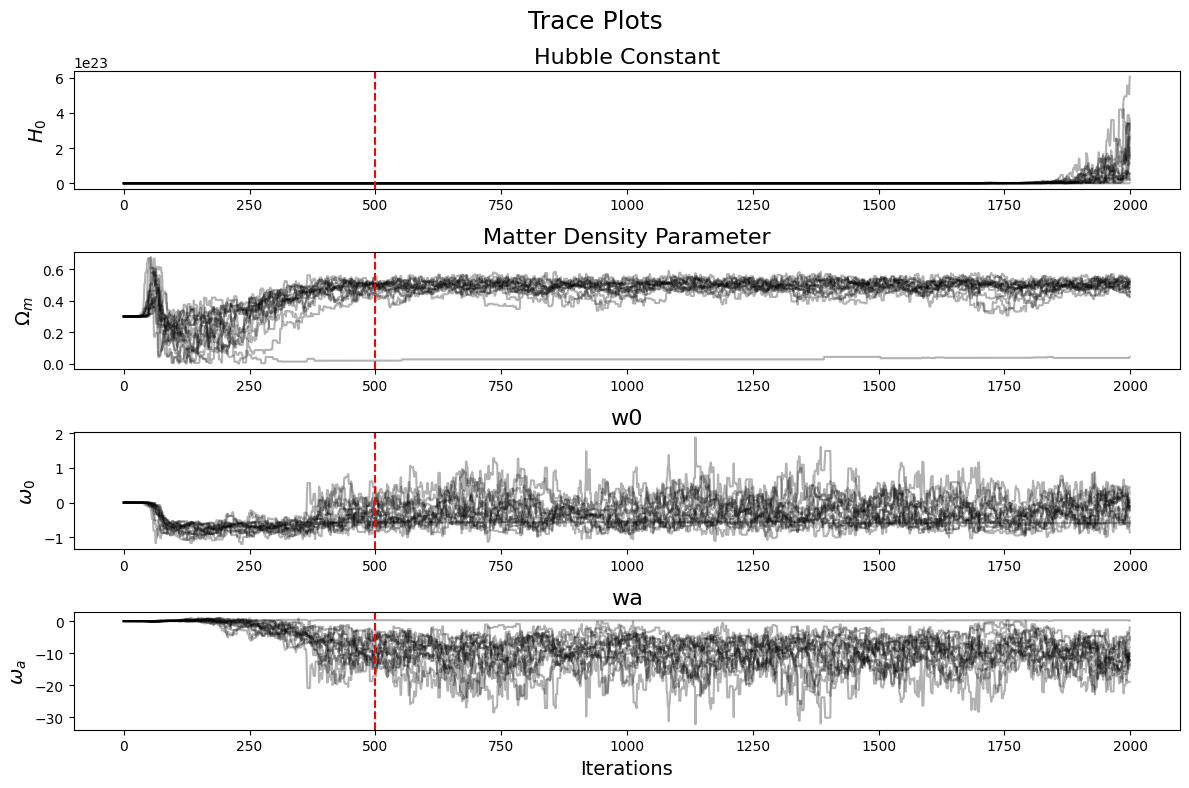

In [ ]:
fw0wa_sampler.trace_plots(500)

In [ ]:
fw0wa_sampler.burned = pd.DataFrame(fw0wa_sampler.get_samples(discard=500, flat=True), columns=['H_0', 'Om_m', 'w0', 'wa'])

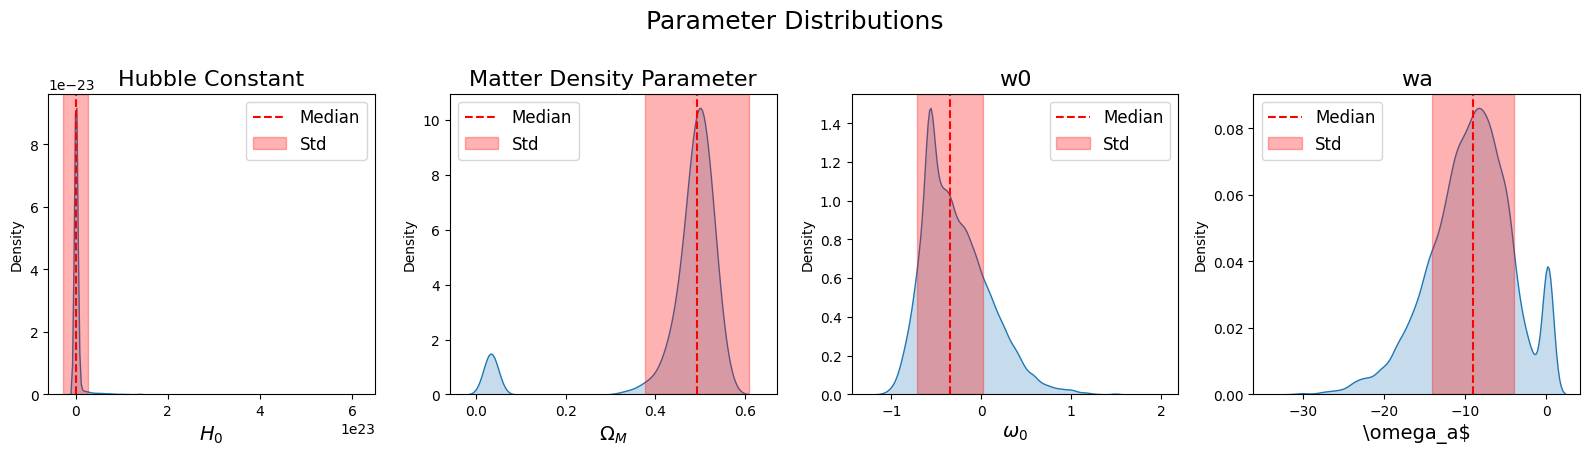

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4.6))

titles = ['Hubble Constant', 'Matter Density Parameter', 'w0', 'wa']
x_labels = [r'$H_0$', r'$\Omega_M$', r'$\omega_0$', r'$\omega_a$']
for i in range(0, 4):
    sns.kdeplot(fw0wa_sampler.burned.iloc[:,i], fill=True, ax=axs[i])
    axs[i].set_xlabel(x_labels[i], size=14)
    axs[i].set_title(titles[i], size=16)
    median = np.median(fw0wa_sampler.burned.iloc[:,i])
    std = np.std(fw0wa_sampler.burned.iloc[:,i])
    axs[i].axvline(median, color='red', linestyle='dashed', label='Median')
    axs[i].axvspan(median-std, median+std, color='red', alpha=0.3, label='Std')
    axs[i].legend(fontsize=12)

fig.suptitle('Parameter Distributions', size=18)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Om_m = {fw0wa_sampler.burned['Om_m'].median():.2f} ± {fw0wa_sampler.burned['Om_m'].std():.2f}")
print(f"w0 = {fw0wa_sampler.burned['w0'].median():.2f} ± {fw0wa_sampler.burned['w0'].std():.2f}")
print(f"wa = {fw0wa_sampler.burned['wa'].median():.2f} ± {fw0wa_sampler.burned['wa'].std():.2f}")

Om_m = 0.49 ± 0.12
w0 = -0.35 ± 0.37
wa = -9.01 ± 5.09


# MatterOnly Model

In [6]:
monly_sampler = CosmologyMCMC(MatterOnlyModel(), df)

n_walkers = 16
n_iterations = 2000
p0 = np.random.multivariate_normal(mean=[73, 0.3], cov=np.diag([1, 1e-12]), size=n_walkers)

monly_sampler.test_priors(p0)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [7]:
monly_sampler.run_mcmc(n_walkers, n_iterations, p0)

100%|██████████| 2000/2000 [07:45<00:00,  4.29it/s]

MatterOnly model took 465.848 seconds


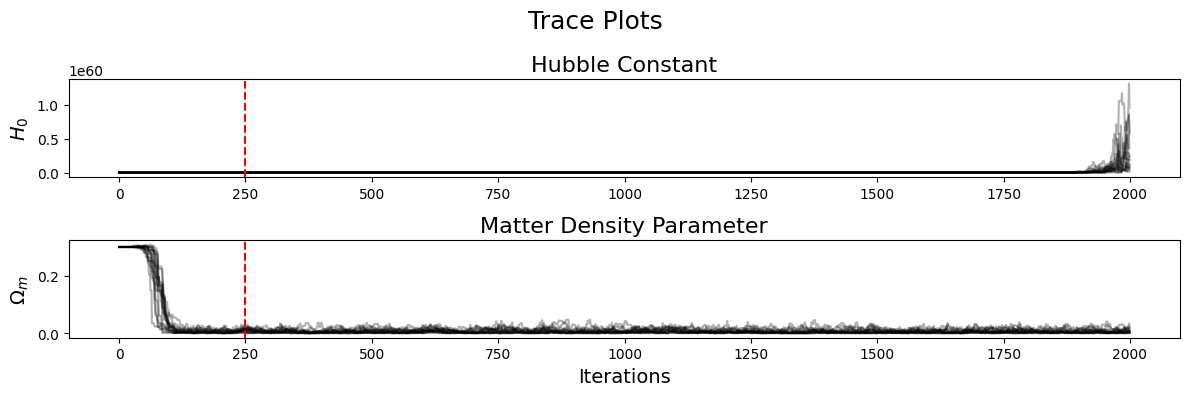

In [8]:
monly_sampler.trace_plots(250)

In [9]:
burned = pd.DataFrame(monly_sampler.get_samples(discard=250, flat=True), columns=['H_0', 'Om_m'])
burned['Om_k'] = 1 - burned['Om_m']
monly_sampler.burned = burned

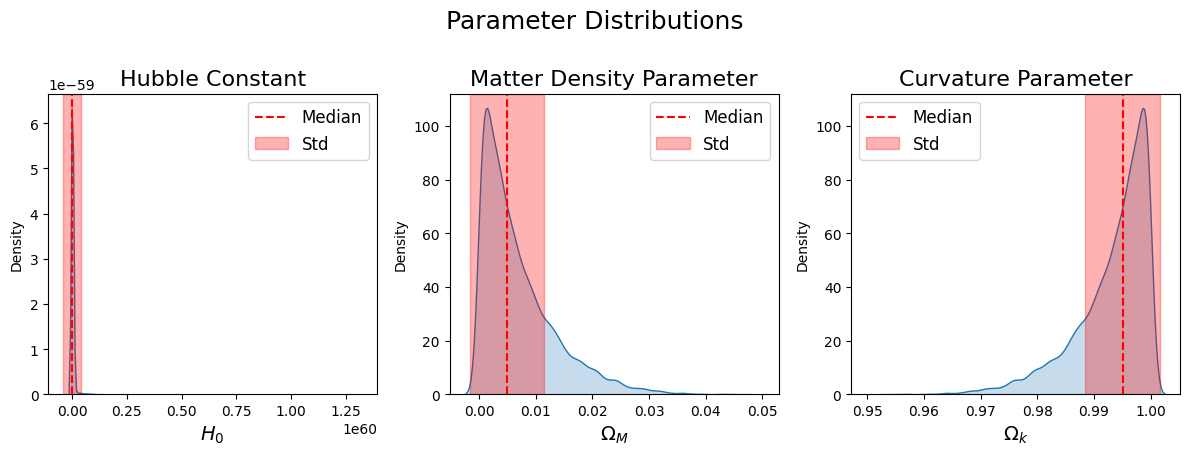

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4.6))

titles = ['Hubble Constant', 'Matter Density Parameter', 'Curvature Parameter']
x_labels = [r'$H_0$', r'$\Omega_M$', r'$\Omega_k$']
for i in range(0, 3):
    sns.kdeplot(monly_sampler.burned.iloc[:,i], fill=True, ax=axs[i])
    axs[i].set_xlabel(x_labels[i], size=14)
    axs[i].set_title(titles[i], size=16)
    median = np.median(monly_sampler.burned.iloc[:,i])
    std = np.std(monly_sampler.burned.iloc[:,i])
    axs[i].axvline(median, color='red', linestyle='dashed', label='Median')
    axs[i].axvspan(median-std, median+std, color='red', alpha=0.3, label='Std')
    axs[i].legend(fontsize=12)

fig.suptitle('Parameter Distributions', size=18)
plt.tight_layout()
plt.show()

In [11]:
print(f"Om_m = {monly_sampler.burned['Om_m'].median():.2f} ± {monly_sampler.burned['Om_m'].std():.2f}")
print(f"Om_k = {monly_sampler.burned['Om_k'].median():.2f} ± {monly_sampler.burned['Om_k'].std():.2f}")


Om_m = 0.00 ± 0.01
Om_k = 1.00 ± 0.01


# Serializing

In [ ]:
lcdm_sampler.burned.to_pickle('cache/lcdm.pkl')
fwcdm_sampler.burned.to_pickle('cache/fwcdm.pkl')
fw0wa_sampler.burned.to_pickle('cache/fw0wa.pkl')
monly_sampler.burned.to_pickle('cache/monly.pkl')